In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.linear_model import LinearRegression, SGDRegressor 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score 
from sklearn.preprocessing import PolynomialFeatures,StandardScaler 

from sklearn.pipeline import Pipeline

# Dataset Loading

<h3>Data Generation Explanation</h3>

<p>
This code generates a <strong>synthetic dataset</strong> with a 
<strong>non-linear (quadratic)</strong> relationship between input 
<strong>X</strong> and output <strong>y</strong>.
</p>

<ul>
  <li>
    <strong>X</strong> contains 200 random values between 
    <strong>&minus;3</strong> and <strong>2</strong>.
  </li>
  <li>
    <strong>y</strong> is created using the quadratic equation:
    <br>
    <strong>y = 0.8X<sup>2</sup> + 0.9X + 2</strong>
  </li>
  <li>
    Random noise is added to <strong>y</strong> to make the data more realistic.
  </li>
</ul>

<p>
This dataset is useful for demonstrating 
<strong>polynomial regression</strong> and understanding 
<strong>non-linear patterns</strong> in machine learning.
</p>


In [2]:
X = 5*np.random.rand(200,1)-3
y = 0.8*X**2 + 0.9*X + 2 + np.random.randn(200,1)

Text(0, 0.5, 'y')

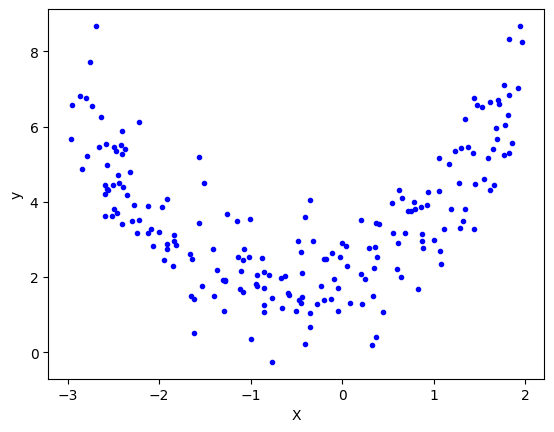

In [5]:
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')


# First we apply simple linear Regression

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state= 42)

In [9]:
lr = LinearRegression()
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
y_pred = lr.predict(X_test)

In [11]:
r2_score(y_test,y_pred)

0.005297550359715131

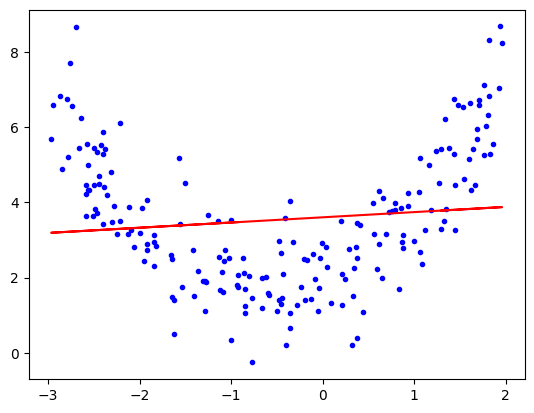

In [12]:
plt.plot(X,y,'b.')
plt.plot(X_train,lr.predict(X_train),color='red')

# Now we apply Polynomial Regression 

In [13]:
poly = PolynomialFeatures(degree= 2, include_bias=True) 

X_train_trans = poly.fit_transform(X_train) 
X_test_trans = poly.transform(X_test) 


In [14]:
X_train[0]

array([-0.9296229])

In [15]:
X_train_trans[0]

array([ 1.        , -0.9296229 ,  0.86419874])

In [16]:
plr = LinearRegression() 
plr.fit(X_train_trans,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
y_predi = plr.predict(X_test_trans)

In [19]:
r2_score(y_test,y_predi)

0.7675006993790678

In [20]:
plr.coef_

array([[0.        , 0.98355656, 0.84911036]])

In [21]:
plr.intercept_

array([2.01465529])

<h3>Prediction on New Data</h3>

<p>
This code is used to predict output values for new input data using the trained
<strong>polynomial regression model</strong>.
</p>

<ul>
  <li>
    <strong>X_new</strong> generates 200 evenly spaced values between
    <strong>&minus;3</strong> and <strong>3</strong>.
    These values represent new input points.
  </li>

  <li>
    <strong>poly.transform(X_new)</strong> converts the new input data into
    polynomial features using the same transformation applied during training.
  </li>

  <li>
    <strong>lr.predict(X_new_poly)</strong> predicts the corresponding output
    values for the new inputs.
  </li>
</ul>

<p>
This step is mainly used to visualize the fitted polynomial curve and to observe
how the model behaves on unseen data.
</p>


In [22]:
X_new = np.linspace(-3,2,200).reshape(200,1)
X_new_poly = poly.transform(X_new) 
y_new = plr.predict(X_new_poly) 

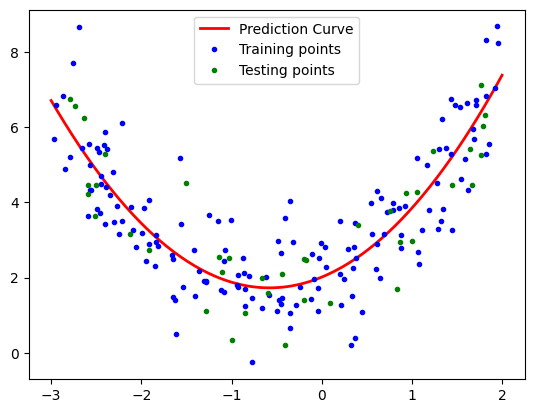

In [25]:
plt.plot(X_new, y_new,'r-',linewidth = 2, label = 'Prediction Curve') 
plt.plot(X_train,y_train,'b.', label = 'Training points')
plt.plot(X_test,y_test,'g.', label = 'Testing points')
plt.legend()

In [26]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 2, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    scaler = StandardScaler()
    polr = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", poly_features),
            ("scaler", scaler),
            ("polr", polr),
        ])
    polynomial_regression.fit(X, y)
    y_new_poly = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_new_poly,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 2, 0, 10])
    plt.show()

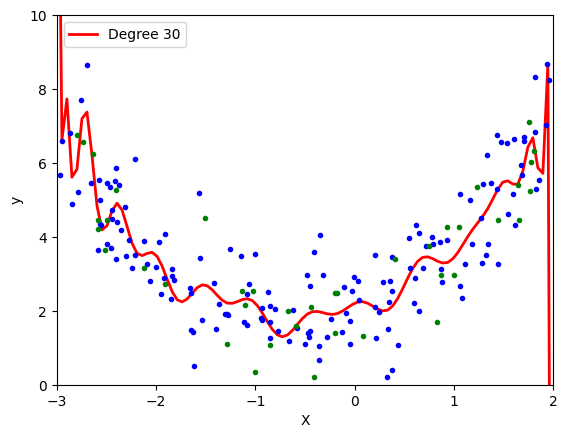

In [27]:
polynomial_regression(30)

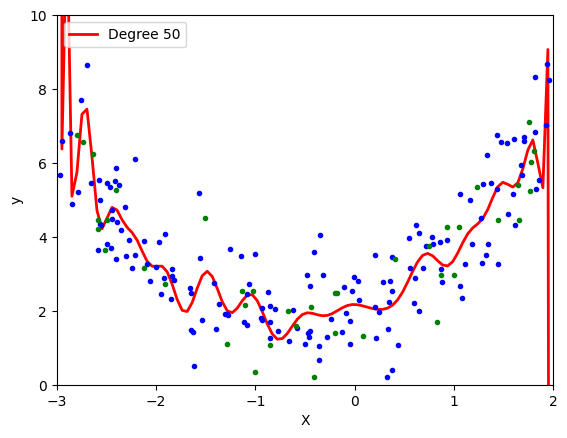

In [28]:
polynomial_regression(50)

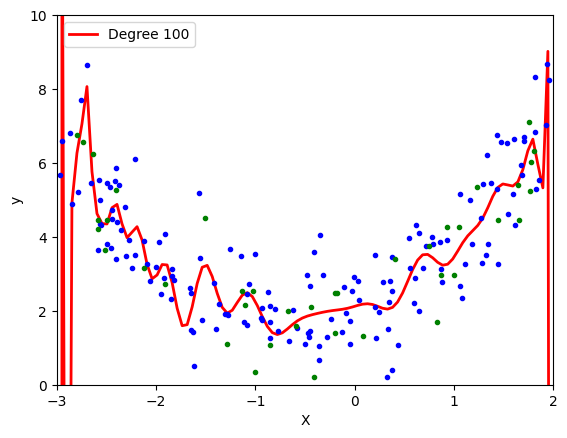

In [29]:
polynomial_regression(100)

# 3D Polynomial Regression 

In [30]:
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

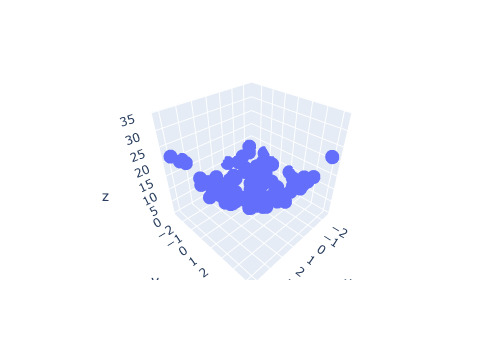

In [31]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [32]:
lrr = LinearRegression()
lrr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lrr.predict(final).reshape(10,10)

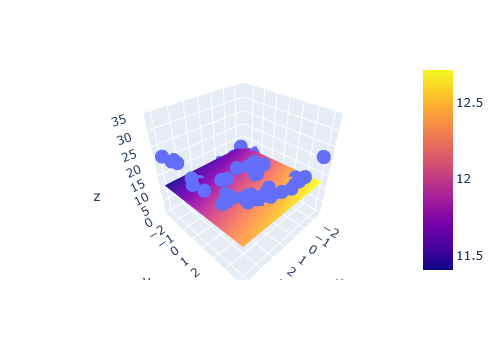

In [33]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [34]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [37]:
polyr = PolynomialFeatures(degree=30)
X_multi_trans = polyr.fit_transform(X_multi)

In [41]:
lir = LinearRegression()
lir.fit(X_multi_trans,z)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:


X_test_multi = polyr.transform(final)



In [44]:


z_final = lir.predict(X_multi_trans).reshape(10,10)



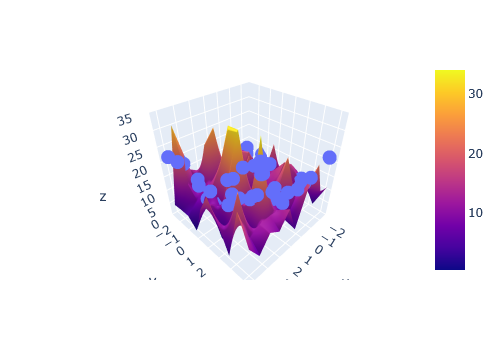

In [45]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()